# Hector Pena
# DSC 680
# Bellevue University

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv('cardiovascular_risk_dataset.csv')
## read csv file

In [3]:
df.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


In [4]:
df.tail()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
5495,5496,19,26.0,121,75,185,84,Never,6724,3,2.9,7.2,No,7,0.0,0.0,Low
5496,5497,18,30.9,128,82,235,75,Never,3661,4,0.0,5.5,No,1,9.6,16.8,Low
5497,5498,63,29.5,142,92,239,69,Never,6643,5,4.1,6.9,No,6,2.4,31.8,Medium
5498,5499,46,27.5,138,91,237,65,Never,3279,3,2.4,5.8,Yes,5,2.3,29.4,Medium
5499,5500,79,29.0,157,102,265,82,Never,3066,5,0.0,7.7,No,5,6.3,50.9,Medium


In [6]:
df.shape

(5500, 17)

In [8]:
df.dtypes

Patient_ID                            int64
age                                   int64
bmi                                 float64
systolic_bp                           int64
diastolic_bp                          int64
cholesterol_mg_dl                     int64
resting_heart_rate                    int64
smoking_status                       object
daily_steps                           int64
stress_level                          int64
physical_activity_hours_per_week    float64
sleep_hours                         float64
family_history_heart_disease         object
diet_quality_score                    int64
alcohol_units_per_week              float64
heart_disease_risk_score            float64
risk_category                        object
dtype: object

In [9]:
df.info

<bound method DataFrame.info of       Patient_ID  age   bmi  systolic_bp  diastolic_bp  cholesterol_mg_dl  \
0              1   62  25.0          142            93                247   
1              2   54  29.7          158           101                254   
2              3   46  36.2          170           113                276   
3              4   48  30.4          153            98                230   
4              5   46  25.3          139            87                206   
...          ...  ...   ...          ...           ...                ...   
5495        5496   19  26.0          121            75                185   
5496        5497   18  30.9          128            82                235   
5497        5498   63  29.5          142            92                239   
5498        5499   46  27.5          138            91                237   
5499        5500   79  29.0          157           102                265   

      resting_heart_rate smoking_status  da

In [10]:
df.isnull().sum()

Patient_ID                          0
age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.describe()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,1587.857571,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,1.000000,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,1375.750000,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,2750.500000,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,4125.250000,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,5500.000000,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

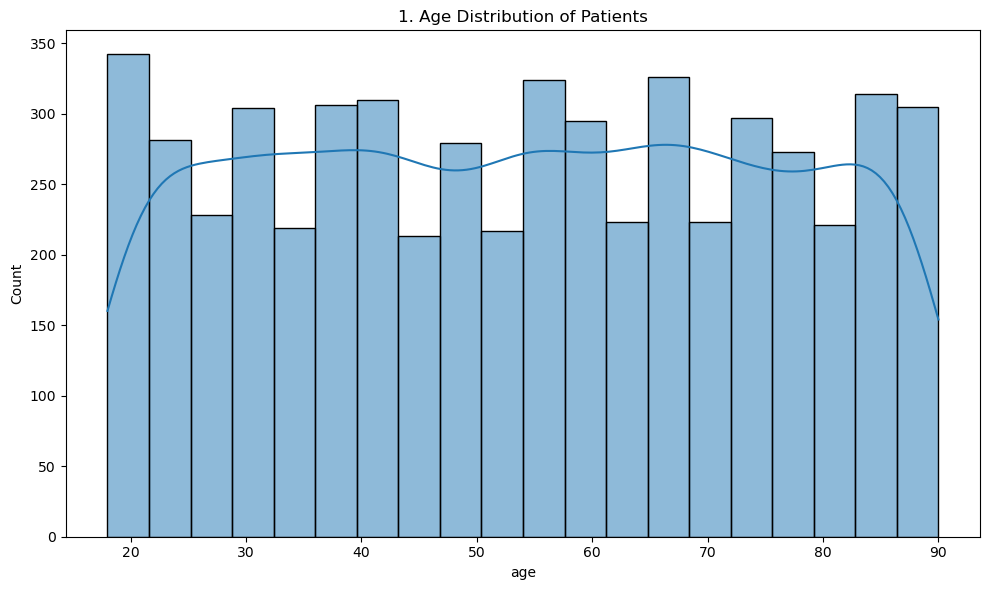

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title(f'{plot_no}. Age Distribution of Patients')
show_fig()
plot_no += 1

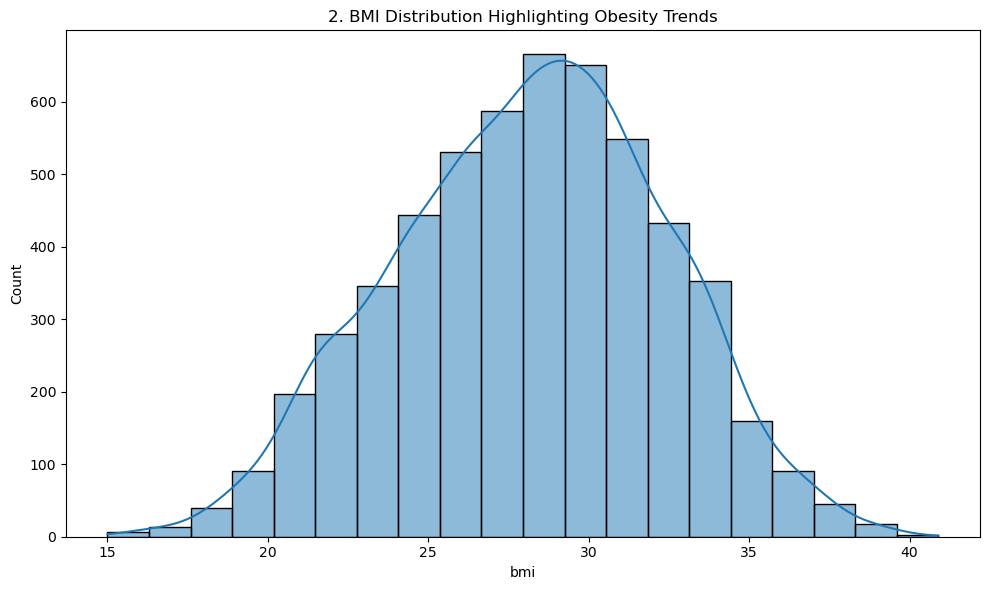

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title(f'{plot_no}. BMI Distribution Highlighting Obesity Trends')
show_fig()
plot_no += 1

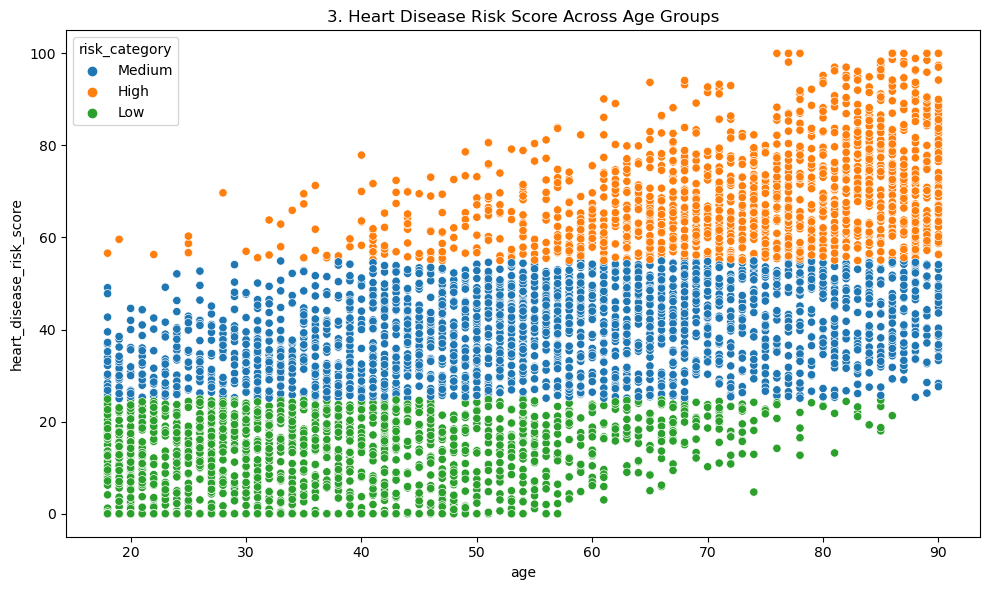

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Heart Disease Risk Score Across Age Groups')
show_fig()
plot_no += 1

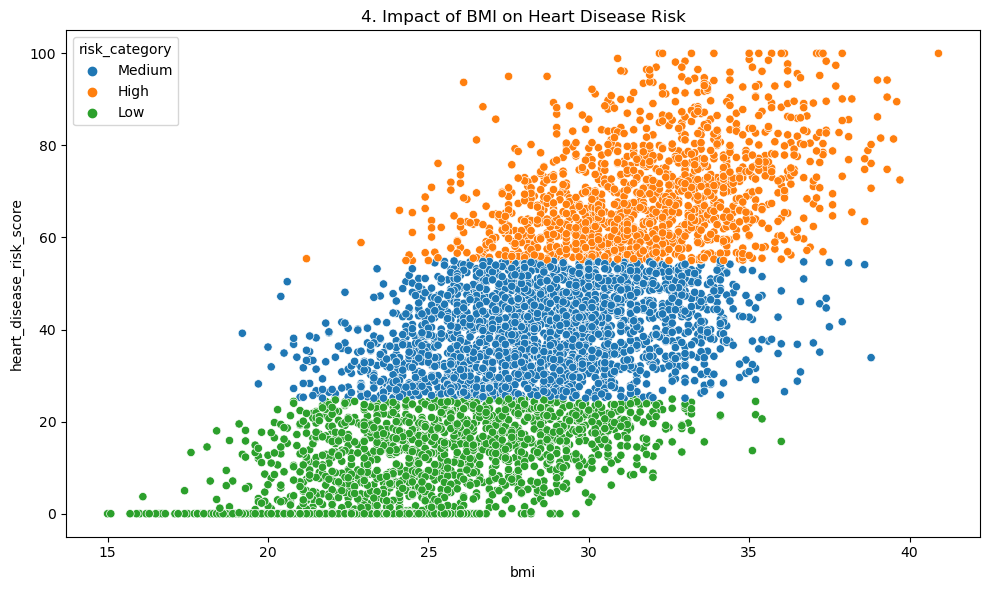

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='bmi', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Impact of BMI on Heart Disease Risk')
show_fig()
plot_no += 1

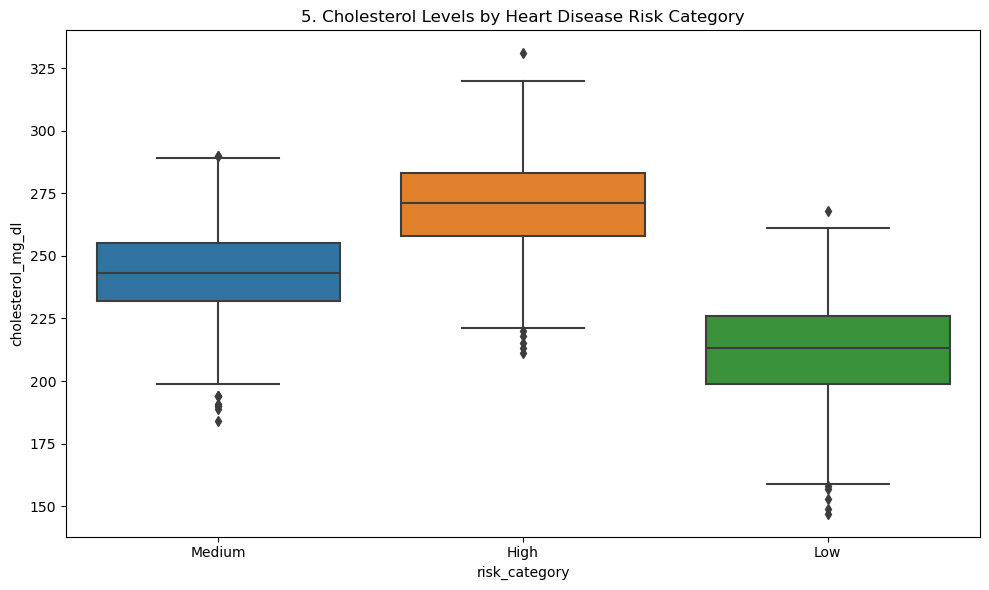

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='risk_category', y='cholesterol_mg_dl')
plt.title(f'{plot_no}. Cholesterol Levels by Heart Disease Risk Category')
show_fig()
plot_no += 1

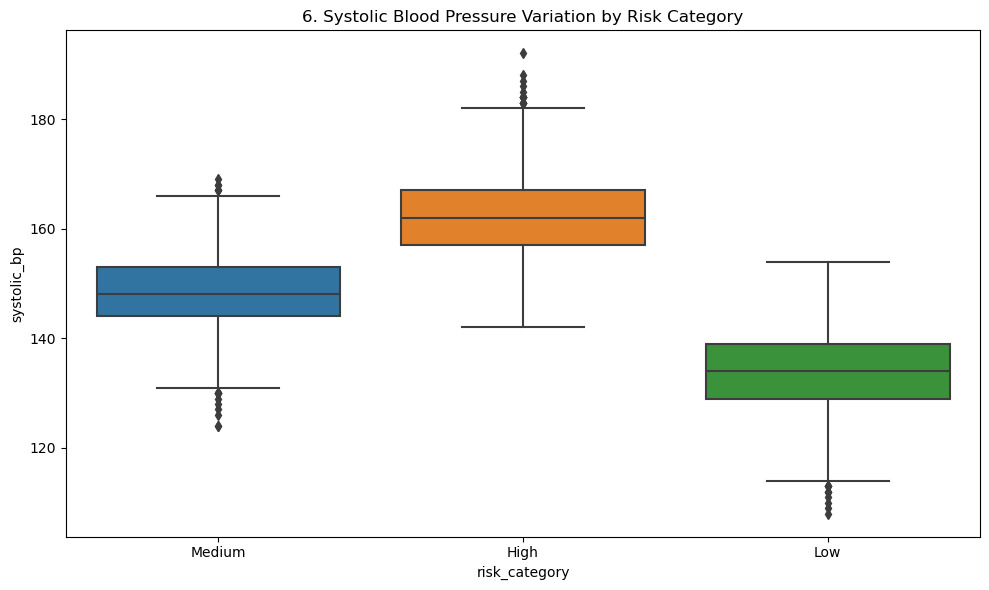

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='risk_category', y='systolic_bp')
plt.title(f'{plot_no}. Systolic Blood Pressure Variation by Risk Category')
show_fig()
plot_no += 1

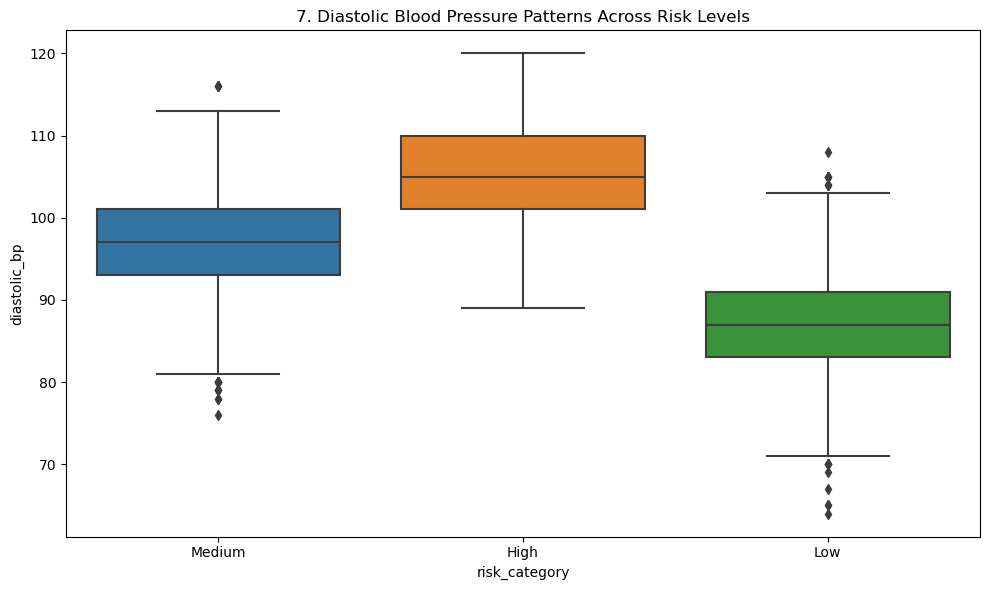

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='risk_category', y='diastolic_bp')
plt.title(f'{plot_no}. Diastolic Blood Pressure Patterns Across Risk Levels')
show_fig()
plot_no += 1

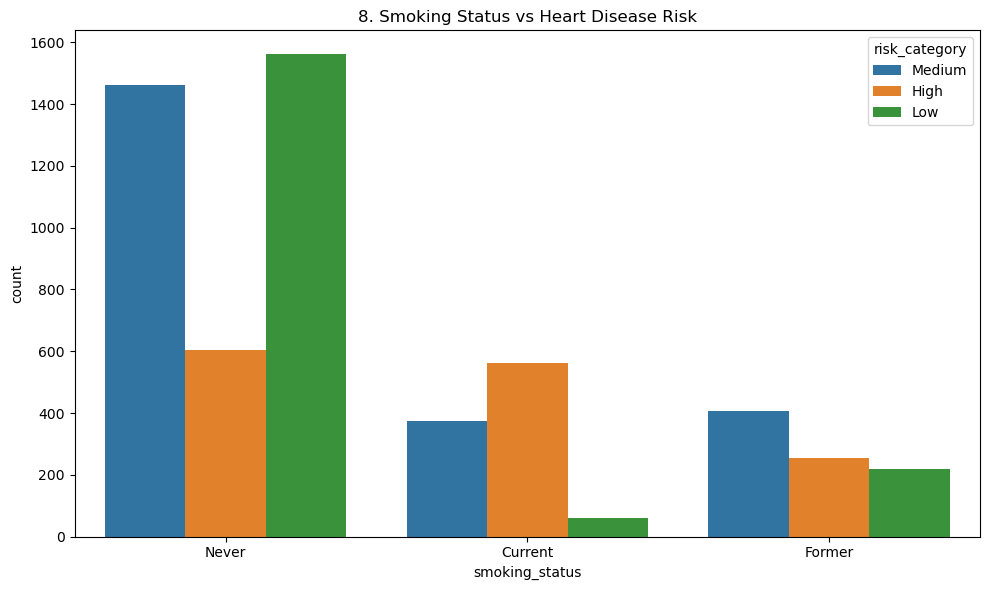

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='smoking_status', hue='risk_category')
plt.title(f'{plot_no}. Smoking Status vs Heart Disease Risk')
show_fig()
plot_no += 1

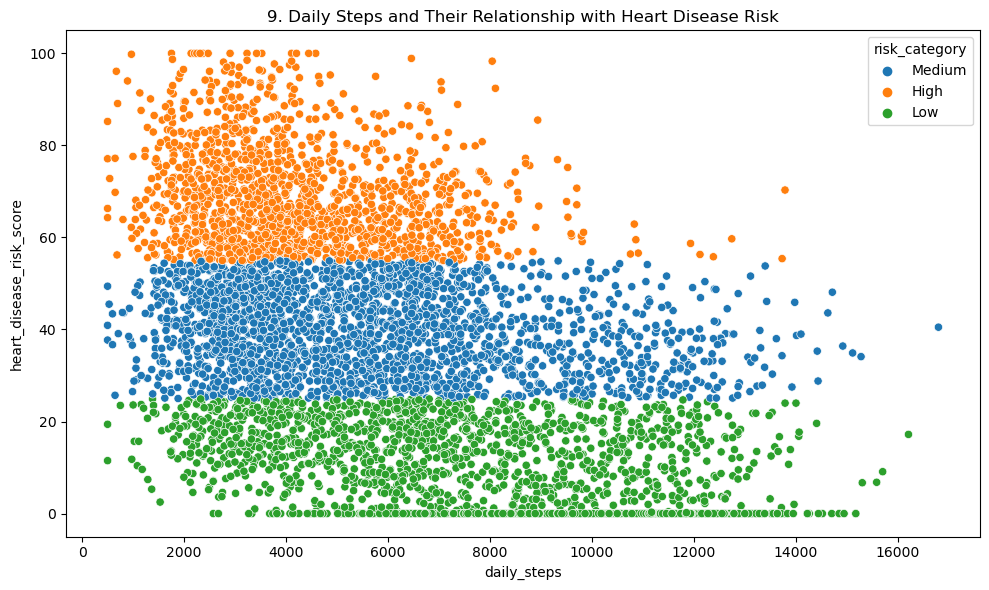

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='daily_steps', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Daily Steps and Their Relationship with Heart Disease Risk')
show_fig()
plot_no += 1

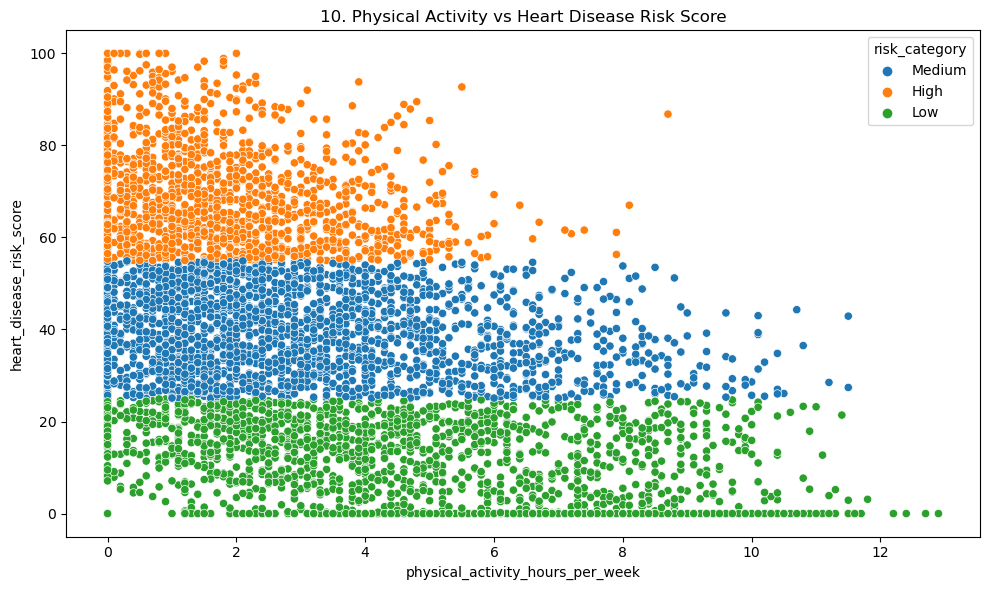

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='physical_activity_hours_per_week', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Physical Activity vs Heart Disease Risk Score')
show_fig()
plot_no += 1

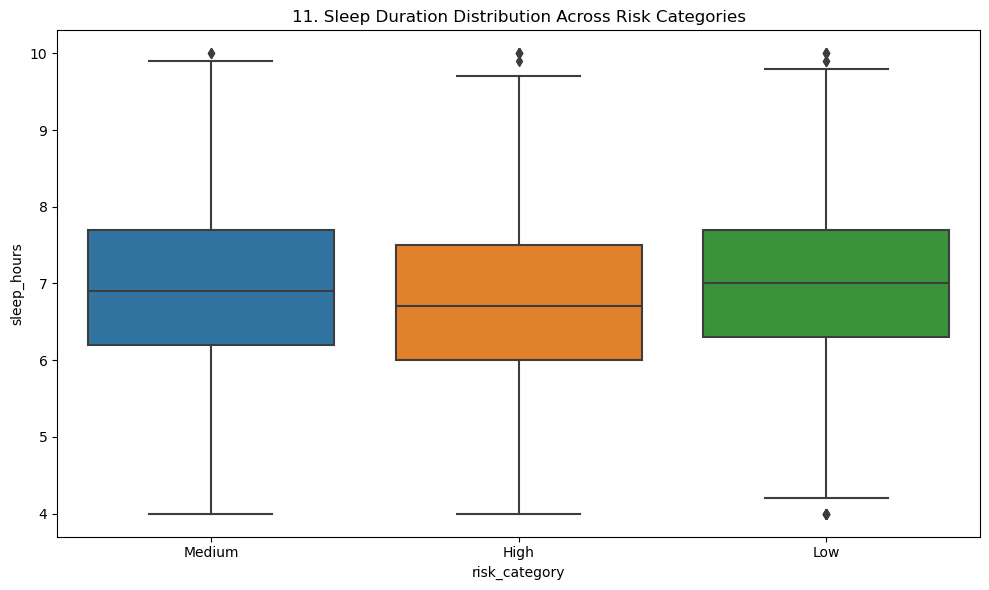

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='risk_category', y='sleep_hours')
plt.title(f'{plot_no}. Sleep Duration Distribution Across Risk Categories')
show_fig()
plot_no += 1

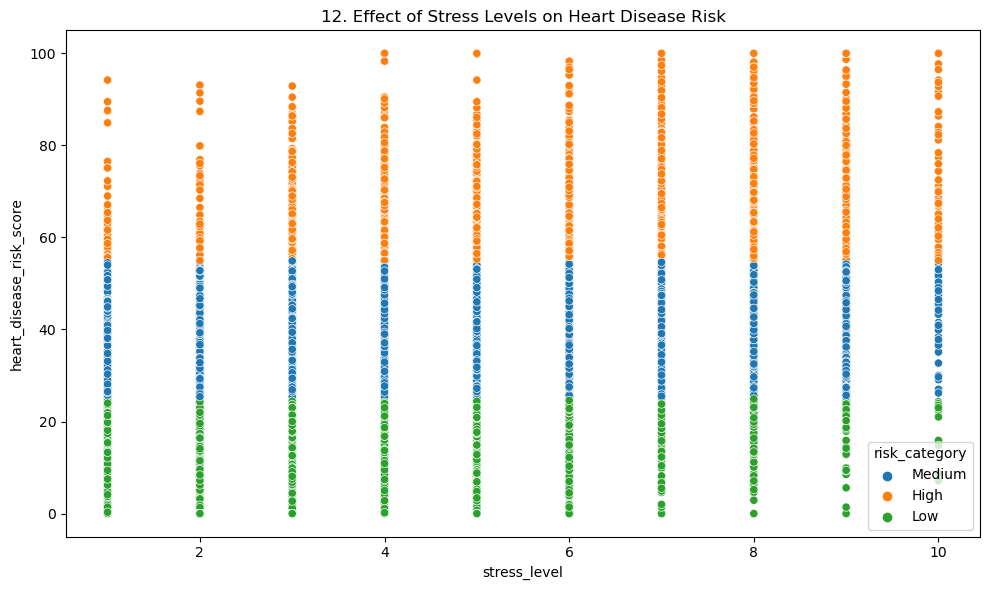

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='stress_level', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Effect of Stress Levels on Heart Disease Risk')
show_fig()
plot_no += 1

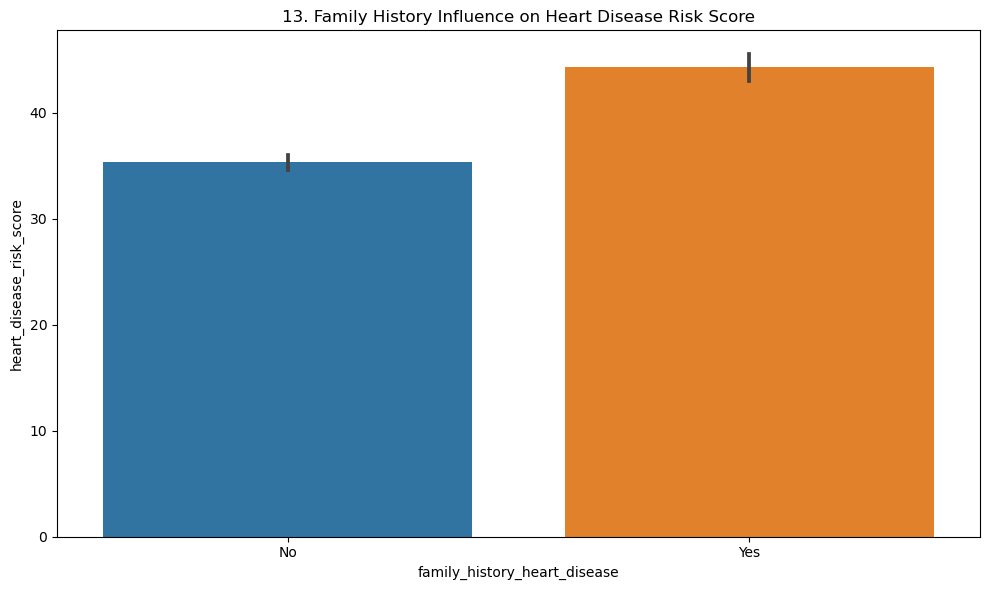

In [32]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='family_history_heart_disease', y='heart_disease_risk_score')
plt.title(f'{plot_no}. Family History Influence on Heart Disease Risk Score')
show_fig()
plot_no += 1

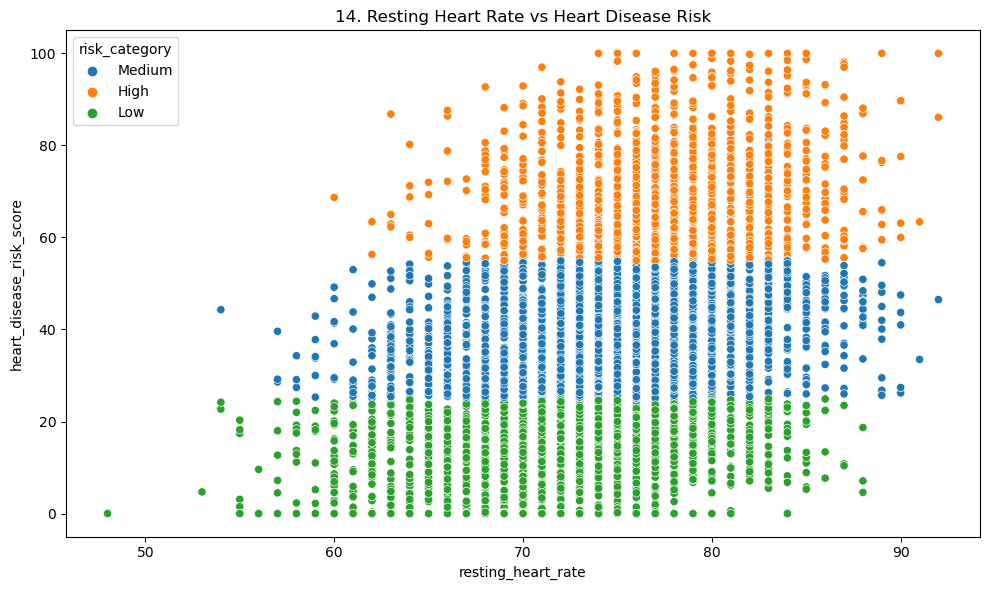

In [33]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='resting_heart_rate', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Resting Heart Rate vs Heart Disease Risk')
show_fig()
plot_no += 1

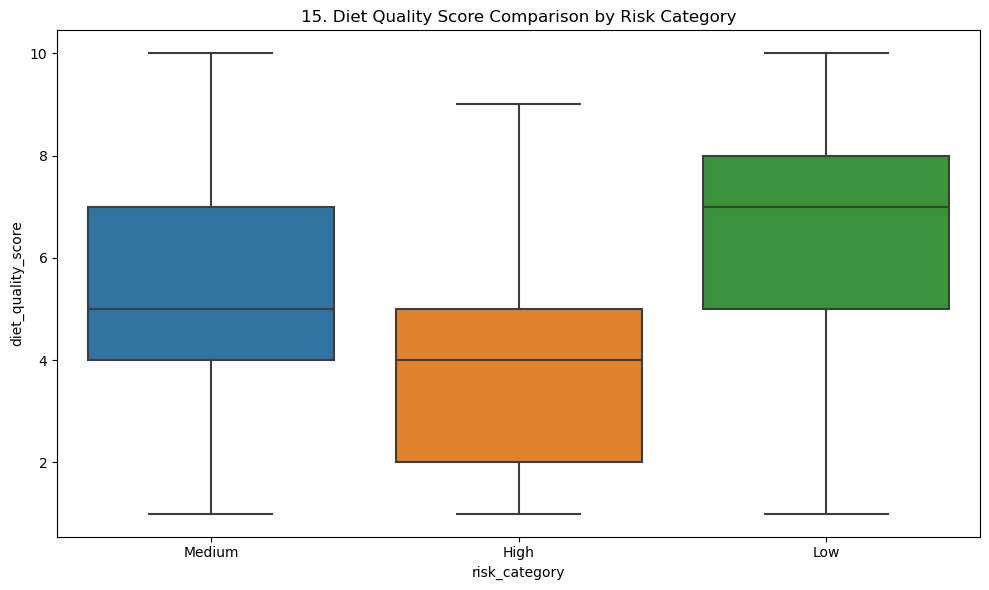

In [34]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='risk_category', y='diet_quality_score')
plt.title(f'{plot_no}. Diet Quality Score Comparison by Risk Category')
show_fig()
plot_no += 1

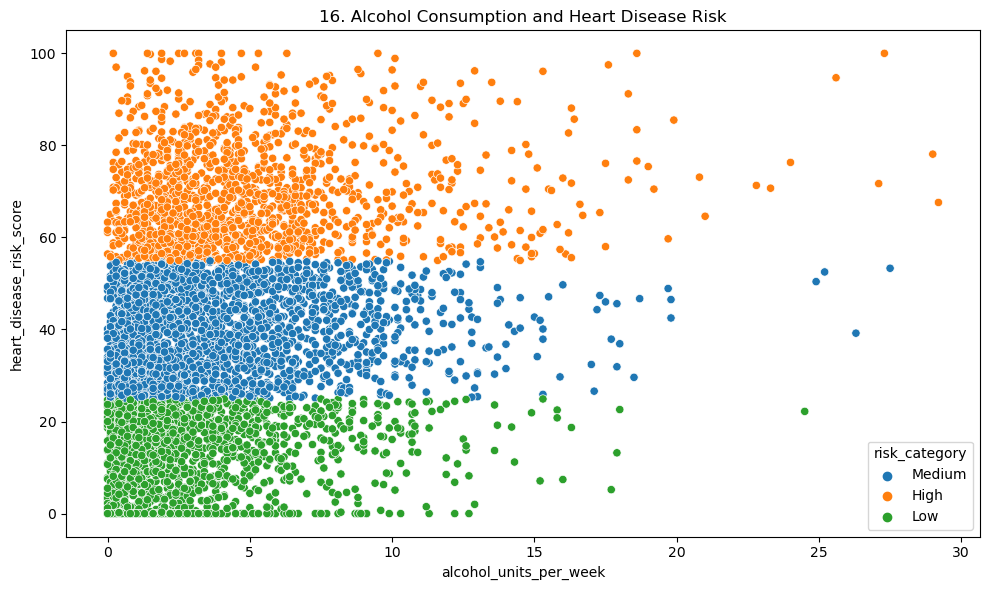

In [35]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='alcohol_units_per_week', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Alcohol Consumption and Heart Disease Risk')
show_fig()
plot_no += 1

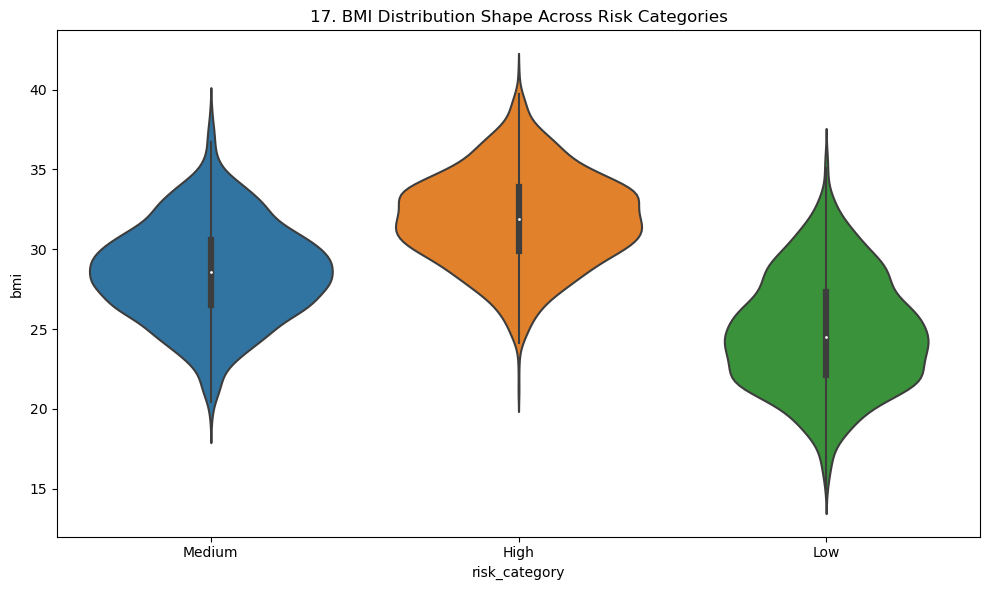

In [36]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='risk_category', y='bmi')
plt.title(f'{plot_no}. BMI Distribution Shape Across Risk Categories')
show_fig()
plot_no += 1

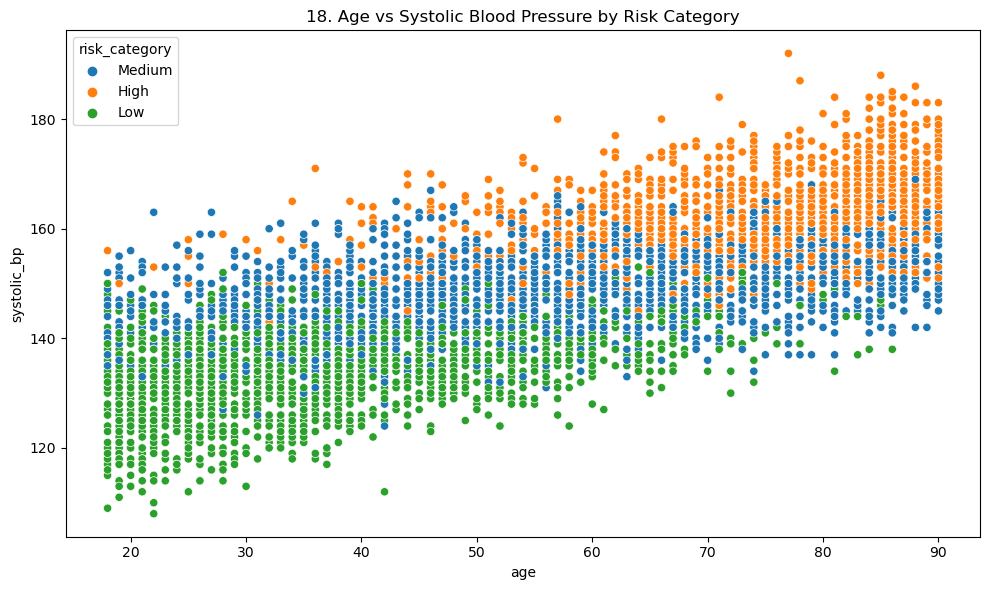

In [37]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='systolic_bp', hue='risk_category')
plt.title(f'{plot_no}. Age vs Systolic Blood Pressure by Risk Category')
show_fig()
plot_no += 1

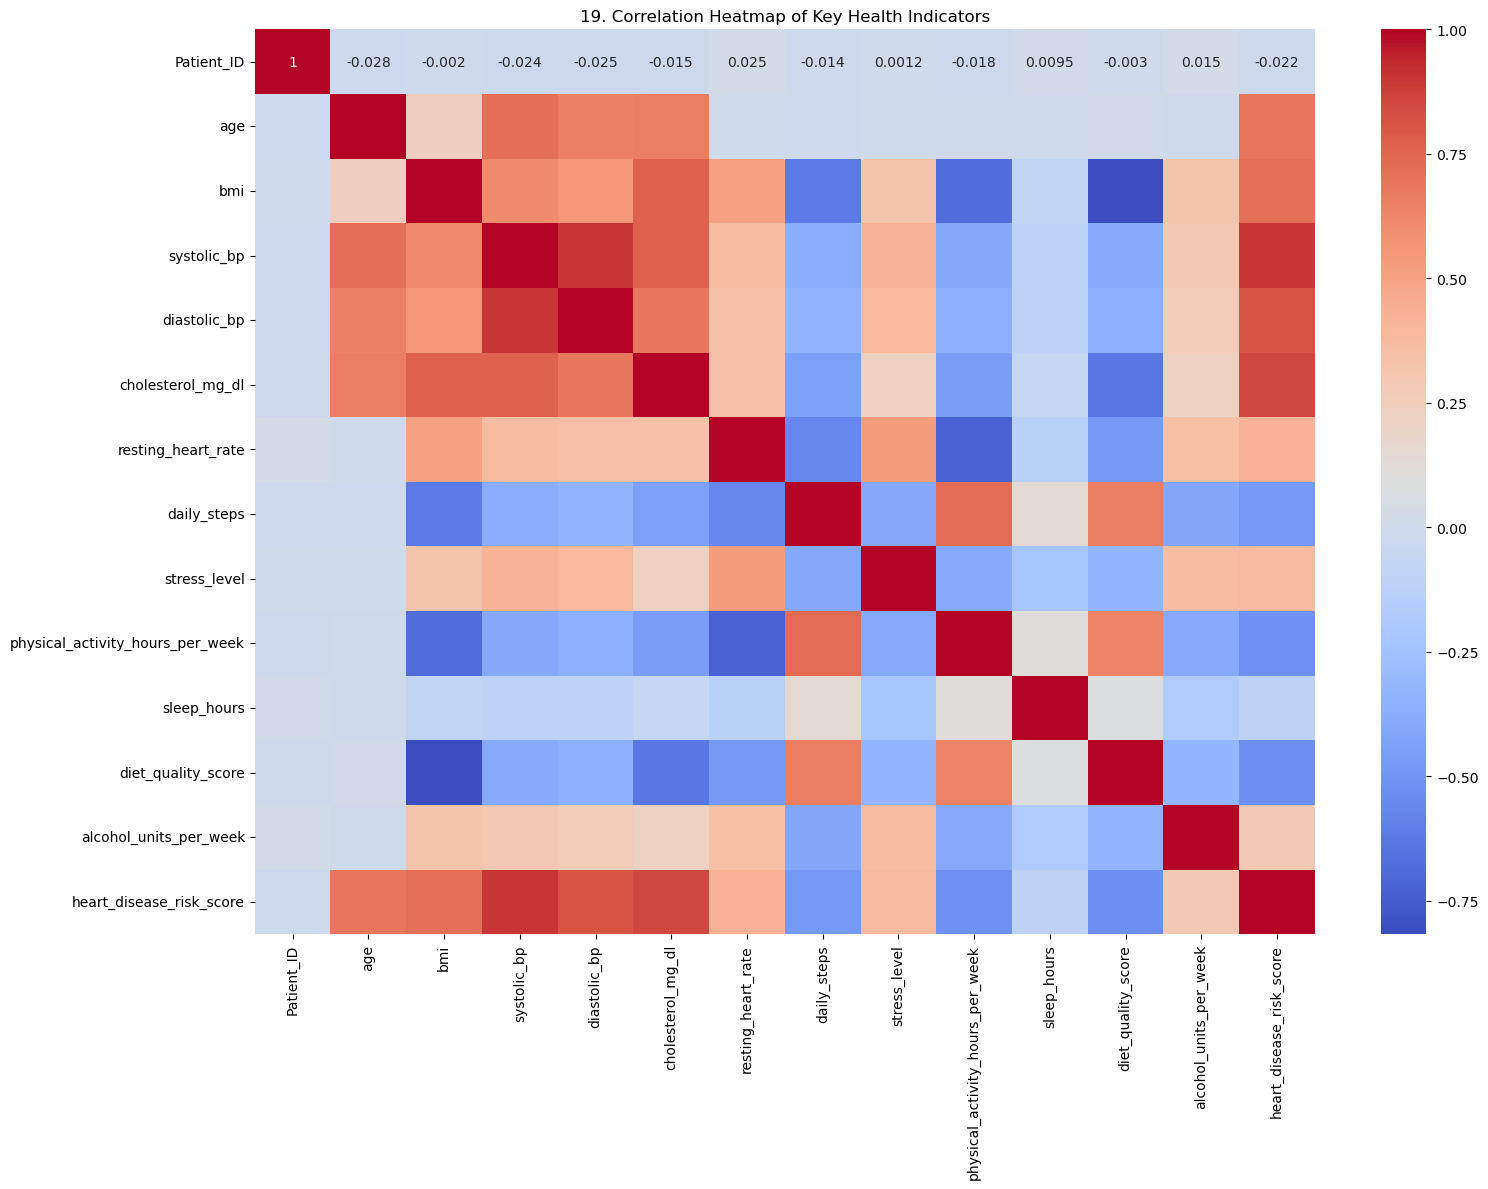

In [38]:
fig = plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Key Health Indicators')
show_fig()
plot_no += 1

In [40]:
X = df.drop(columns=['Patient_ID', 'risk_category'])
y = df['risk_category']

In [41]:
X = pd.get_dummies(X, drop_first=True)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [45]:
y_pred = model.predict(X_test_scaled)

In [46]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9755


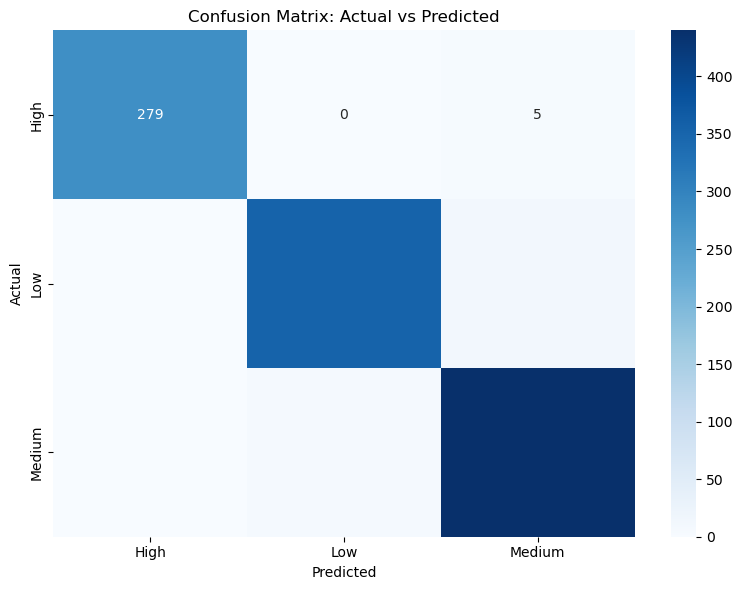

In [47]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title('Confusion Matrix: Actual vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()